# Machine Learning Project - Group 33

- Beatriz Correia, 20250434
- Beatriz Pinto, 20250364
- Diogo Braga, 20250412
- Marta Feital, 20250407

## Index
* [Abstract](#chapter1)
* [Business Needs](#chapter2)
* [Libraries](#chapter3)
* [Data Understanding](#chapter4)
    * [Train](#section_4_1)
    * [Test](#section_4_2)
* [Data Preprocessing](#chapter5)
    * [Drop columns that are not useful for the model](#section_5_1)
    * [Data Inconsistencies and Missing Values](#section_5_2)
    * [Outliers Detection and Treatment](#section_5_3)
* [Feature Engineering](#chapter6)
* [Data Exploration](#chapter7)
* [Benchmarking](#chapter8)
    * [Hyperparameter Tuning](#section_8_1)
        * [Random Forest](#section_8_1_1)
        * [KNN](#section_8_1_2)
        * [Performance Comparison](#section_8_1_3)
    * [Ensemble](#section_8_3)
* [Deployment](#chapter9)
* [Conclusions](#chapter10)

## Abstract <a class="anchor" id="chapter1"></a>

The rapid growth of online car resale platforms has increased the demand for fast and reliable vehicle price evaluations. Cars 4 You, an online car resale company, currently relies on physical inspections performed by mechanics to assess vehicle prices, which has led to long waiting times and loss of potential customers. To address this challenge, this project aims to develop a machine learning–based regression model capable of accurately predicting car prices using only the information provided by users when registering a vehicle.

This comprehensive data science pipeline includes data cleaning, handling of missing values, outlier treatment, and extensive feature engineering. Features unavailable at prediction time were removed to ensure realistic deployment conditions. Three encoding strategies were applied to categorical variables, and engineered features were introduced to capture non-linear relationships. Multiple regression models were evaluated using 5-fold cross-validation, with Mean Absolute Error (MAE) selected as the primary evaluation metric due to its interpretability in a pricing context.
The results show that tree-based models outperform linear approaches, with Random Forest achieving the best overall performance. Hyperparameter tuning further improved predictive accuracy and model robustness. Although ensemble methods were explored, the tuned Random Forest model provided the most consistent and reliable results.

The final model enables Cars 4 You to reduce evaluation time, improve operational efficiency, and provide a better customer experience overall, while maintaining accurate vehicle price predictions.

## Business Needs <a class="anchor" id="chapter2"></a>

Cars 4 You has operational inefficiencies due to its reliance on manual vehicle inspections to determine car prices. This process increases evaluation time and reduces the company’s ability to function efficiently. The primary goal of this project is to create an automated pricing system capable of accurately predicting car prices using only information provided by the users when introducing a vehicle.
From a business perspective, the model must ensure consistent price estimates across a wide variety of vehicle characteristics while minimising prediction errors that could negatively impact profits or the relationship with customers.

The project followed a structured machine learning pipeline, including data understanding, preprocessing, feature engineering, model training and evaluation. Features unavailable at prediction time were removed and data quality issues commonly found in real-world datasets were handled.

Model performance was assessed using 5-fold cross-validation, ensuring that there were good results and they were not dependent on a single train–test split. Mean Absolute Error (MAE) was adopted as the primary evaluation metric, complemented by RMSE and adjusted R² to assess model stability and explanatory power. Cross-validation was performed with fold-specific preprocessing and encoding to prevent data leakage.

## Libraries <a class="anchor" id="chapter3"></a>

In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor

## Data Understanding <a class="anchor" id="chapter4"></a>

<table style="width:50%; font-size:12px; border-collapse: collapse; margin: 0 auto; text-align: left;">
  <thead>
    <tr style="background-color:#f2f2f2; text-align:left; color: black;">
      <th style="border:1px solid #ddd;">Attribute</th>
      <th style="border:1px solid #ddd;">Description</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="border:1px solid #ddd;">carID</td><td style="border:1px solid #ddd;">An attribute that contains an identifier for each car</td></tr>
    <tr><td style="border:1px solid #ddd;">Brand</td><td style="border:1px solid #ddd;">The car’s main brand (e.g. Ford, Toyota)</td></tr>
    <tr><td style="border:1px solid #ddd;">model</td><td style="border:1px solid #ddd;">The car model</td></tr>
    <tr><td style="border:1px solid #ddd;">year</td><td style="border:1px solid #ddd;">The year of Registration of the Car</td></tr>
    <tr><td style="border:1px solid #ddd;">mileage</td><td style="border:1px solid #ddd;">The total reported distance travelled by the car (in miles)</td></tr>
    <tr><td style="border:1px solid #ddd;">tax</td><td style="border:1px solid #ddd;">The amount of road tax (in £) that, in 2020, was applicable to the car in question.</td></tr>
    <tr><td style="border:1px solid #ddd;">fuelType</td><td style="border:1px solid #ddd;">Type of Fuel used by the car (Diesel, Petrol, Hybrid, Electric)</td></tr>
    <tr><td style="border:1px solid #ddd;">mpg</td><td style="border:1px solid #ddd;">Average Miles per Gallon</td></tr>
    <tr><td style="border:1px solid #ddd;">engineSize</td><td style="border:1px solid #ddd;">Size of Engine in liters (Cubic Decimeters)</td></tr>
    <tr><td style="border:1px solid #ddd;">paintQuality%</td><td style="border:1px solid #ddd;">The mechanic’s assessment of the cars’ overall paint quality and hull integrity (filled by the mechanic during evaluation)</td></tr>
    <tr><td style="border:1px solid #ddd;">previousOwners</td><td style="border:1px solid #ddd;">Number of previous registered owners of the vehicle</td></tr>
    <tr><td style="border:1px solid #ddd;">hasDamage</td><td style="border:1px solid #ddd;">Boolean marker filled by the seller at the time of registration stating whether the car is damaged or not</td></tr>
    <tr><td style="border:1px solid #ddd;">price</td><td style="border:1px solid #ddd;">The car’s price when purchased by Cars 4 You (in £)</td></tr>
  </tbody>
</table>


### Train <a class="anchor" id="section_4_1"></a>

In [57]:
train_cars = pd.read_csv("project_data/train.csv")
print(f"The train dataset has {train_cars.shape[0]} rows and {train_cars.shape[1]} columns")

The train dataset has 75973 rows and 14 columns


In [58]:
train_cars.head()

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0


In [59]:
train_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   year            74482 non-null  float64
 4   price           75973 non-null  int64  
 5   transmission    74451 non-null  object 
 6   mileage         74510 non-null  float64
 7   fuelType        74462 non-null  object 
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB


In [60]:
train_cars.isna().sum()

carID                0
Brand             1521
model             1517
year              1491
price                0
transmission      1522
mileage           1463
fuelType          1511
tax               7904
mpg               7926
engineSize        1516
paintQuality%     1524
previousOwners    1550
hasDamage         1548
dtype: int64

In [61]:
train_cars.duplicated().sum()

np.int64(0)

In [62]:
train_cars.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
carID,75973.0,NaN,NaN,NaN,37986.0,21931.660338,0.0,18993.0,37986.0,56979.0,75972.0
Brand,74452,72,Ford,14808,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,74456,735,Focus,6353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,74482.0,NaN,NaN,NaN,2017.096611,2.208704,1970.0,2016.0,2017.0,2019.0,2024.121759
price,75973.0,NaN,NaN,NaN,16881.889553,9736.926322,450.0,10200.0,14699.0,20950.0,159999.0
transmission,74451,40,Manual,38050,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,74510.0,NaN,NaN,NaN,23004.184088,22129.788366,-58540.574478,7423.25,17300.0,32427.5,323000.0
fuelType,74462,34,Petrol,37995,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tax,68069.0,NaN,NaN,NaN,120.329078,65.521176,-91.12163,125.0,145.0,145.0,580.0
mpg,68047.0,NaN,NaN,NaN,55.152666,16.497837,-43.421768,46.3,54.3,62.8,470.8


### Test <a class="anchor" id="section_4_2"></a>

In [63]:
test_cars = pd.read_csv("project_data/test.csv")
print(f"The test dataset has {test_cars.shape[0]} rows and {test_cars.shape[1]} columns")

The test dataset has 32567 rows and 13 columns


In [64]:
test_cars.head()

,carID,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,89856,Hyundai,I30,2022.878006,Automatic,30700.000000,petrol,205.0,41.5,1.6,61.0,3.0,0.0
1,106581,VW,Tiguan,2017.000000,Semi-Auto,-48190.655673,Petrol,150.0,38.2,2.0,60.0,2.0,0.0
2,80886,BMW,2 Series,2016.000000,Automatic,36792.000000,Petrol,125.0,51.4,1.5,94.0,2.0,0.0
3,100174,Opel,Grandland X,2019.000000,Manual,5533.000000,Petrol,145.0,44.1,1.2,77.0,1.0,0.0
4,81376,BMW,1 Series,2019.000000,Semi-Auto,9058.000000,Diesel,150.0,51.4,2.0,45.0,4.0,0.0


In [65]:
test_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32567 entries, 0 to 32566
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           32567 non-null  int64  
 1   Brand           31918 non-null  object 
 2   model           31917 non-null  object 
 3   year            31914 non-null  float64
 4   transmission    31944 non-null  object 
 5   mileage         31878 non-null  float64
 6   fuelType        31911 non-null  object 
 7   tax             29259 non-null  float64
 8   mpg             29279 non-null  float64
 9   engineSize      31939 non-null  float64
 10  paintQuality%   31942 non-null  float64
 11  previousOwners  31970 non-null  float64
 12  hasDamage       31970 non-null  float64
dtypes: float64(8), int64(1), object(4)
memory usage: 3.2+ MB


In [66]:
test_cars.isna().sum()

carID                0
Brand              649
model              650
year               653
transmission       623
mileage            689
fuelType           656
tax               3308
mpg               3288
engineSize         628
paintQuality%      625
previousOwners     597
hasDamage          597
dtype: int64

In [67]:
test_cars.duplicated().sum()

np.int64(0)

In [68]:
test_cars.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
carID,32567.0,NaN,NaN,NaN,92256.0,9401.427445,75973.0,84114.5,92256.0,100397.5,108539.0
Brand,31918,64,Ford,6360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,31917,593,Focus,2721,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,31914.0,NaN,NaN,NaN,2017.102299,2.207969,1991.0,2016.0,2017.0,2019.0,2024.121759
transmission,31944,38,Manual,16312,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,31878.0,NaN,NaN,NaN,22952.658921,22132.758713,-58540.574478,7298.25,17225.5,32500.0,279000.0
fuelType,31911,29,Petrol,16113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tax,29259.0,NaN,NaN,NaN,120.569239,65.56057,-91.12163,125.0,145.0,145.0,580.0
mpg,29279.0,NaN,NaN,NaN,55.210728,17.644635,-43.421768,46.3,54.3,62.8,470.8
engineSize,31939.0,NaN,NaN,NaN,1.665377,0.574467,-0.103493,1.2,1.6,2.0,6.6


## Data Preprocessing <a class="anchor" id="chapter5"></a>

### Drop columns that are not useful for the model <a class="anchor" id="section_5_1"></a>

The variable paintQuality% is assessed during vehicle inspection and is not available at the time of prediction. For this reason, it is not used in the final predictive models and was therefore removed, as was the variable hasDamage, which has only a single value in the available data

In [69]:
train_cars = train_cars.drop(['paintQuality%', 'hasDamage'], axis=1)
test_cars = test_cars.drop(['paintQuality%', 'hasDamage'], axis=1)

### Data Inconsistencies and Missing Values <a class="anchor" id="section_5_2"></a>

In [70]:
def column_treatment(df):
    """
    Standardizes column names for consistency.

    By eliminating spaces, converting to lowercasein order to standardize column names.

    It receives a dataframe and returns the dataframe with cleaned column names.
    """
    
    df = df.copy()
    df.columns = [col.strip().lower() for col in df.columns]
    replacements = {
        "fueltype": "fuel_type",
        "previousowners": "previous_owners",
        "enginesize": "engine_size",
    }
    df.columns = [replacements.get(col, col) for col in df.columns]
    return df

train_cars = column_treatment(train_cars)
test_cars = column_treatment(test_cars)

In [71]:
def convert_to_int(df, cols):
    """
    Converts selected columns to integer type after filling missing 
    values with zero.

    The function receives a dataframe and a list of strings with the 
    names of columns to convert and returns the dataframe with the 
    columns converted.
    """
    
    df = df.copy()
    df[cols] = df[cols].fillna(0).astype(int)
    return df

In [ ]:
def convert_to_positive(df, cols):
    """
    This function converts selected numerical columns to non-negative using the absolute value function.
    It is used to correct data entry errors.

    Receives a dataframe and a list of column names to convert and returns the modified dataframe.
    """
    
    df = df.copy()
    df[cols] = df[cols].abs()
    return df

### Outliers Detection and Treatment <a class="anchor" id="section_5_3"></a>

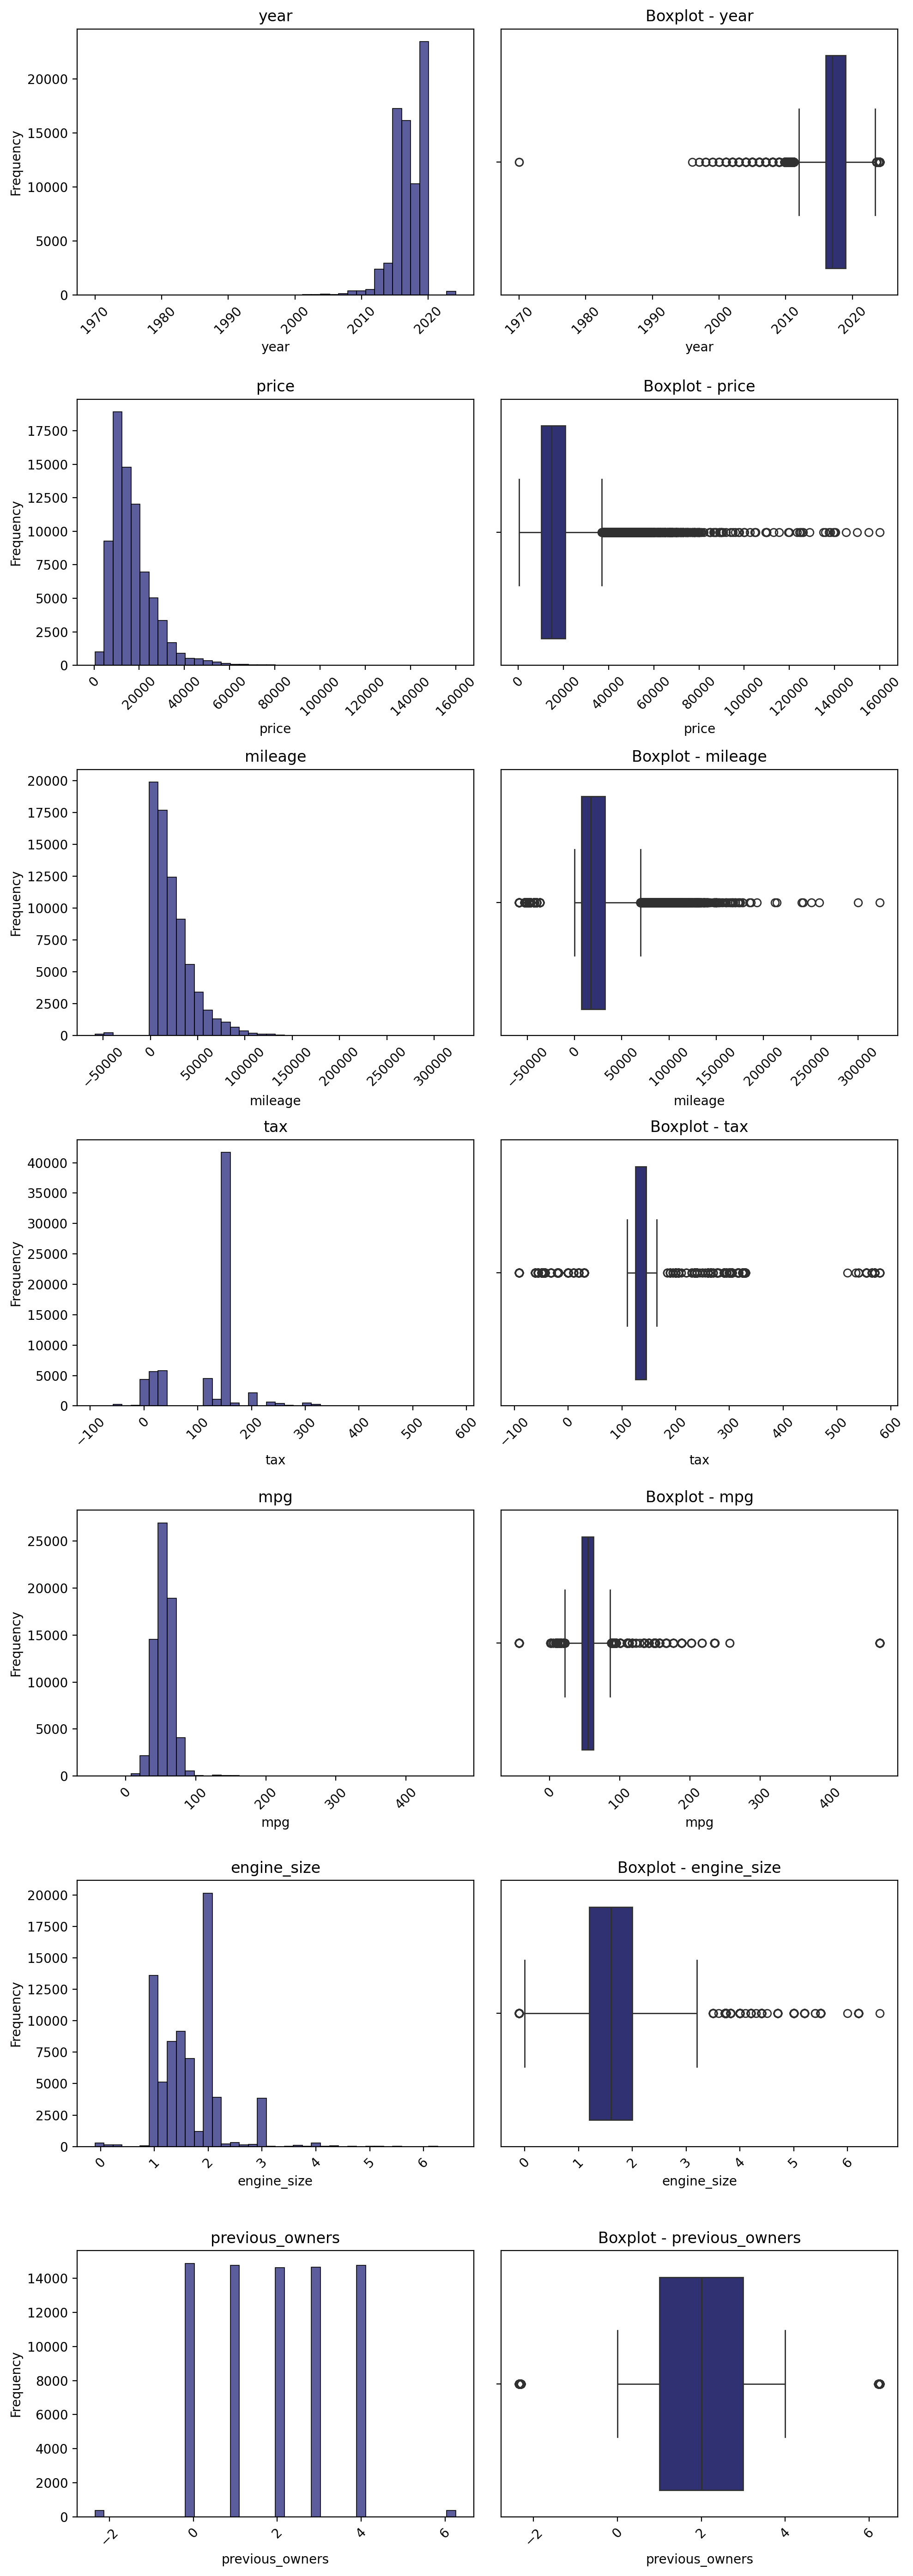

In [73]:
metric_features_train = train_cars.select_dtypes(include=['number']).columns.drop("carid")

n_rows_subplot = len(metric_features_train)
n_cols_subplot = 2

fig, axes = plt.subplots(n_rows_subplot, n_cols_subplot, figsize=(10, 4 * n_rows_subplot), dpi=200)

for i, col in enumerate(metric_features_train):    
    sns.histplot(train_cars[col], kde=False, bins=40, color="#24277D", ax=axes[i][0])
    axes[i][0].set_title(f"{col}")
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel("Frequency")
    axes[i][0].tick_params(axis="x", rotation=45)

    
    sns.boxplot(x=train_cars[col], color="#24277D", ax=axes[i][1])
    axes[i][1].set_title(f"Boxplot - {col}")
    axes[i][1].set_xlabel(col)
    axes[i][1].set_ylabel("")
    axes[i][1].tick_params(axis="x", rotation=45)


plt.tight_layout()
plt.show()

In [74]:
def handle_outliers_domain(df):
    """
    Handles outliers using common knowledge.
    This function is applied before cross validation and does not use target information.

    What we know:
    - year must be capped at 2020
    - mileage must be non-negative (>= 0)
    - engine_size < 0.1 will be treated as a missing value
    - mpg outside [10, 120] will also be treated as a missing value
    - previous_owners must be non-negative (>= 0)

    The function receives a dataset and returns the dataset with the outliers handled.
    """
    
    df = df.copy()

    # Dataset is from 2020 so the limit for this value is 2020
    df.loc[df["year"] > 2020, "year"] = 2020

    # Mileage and previous owners can't be negative
    df.loc[df["mileage"] < 0, "mileage"] = np.nan
    df.loc[df["previous_owners"] < 0, "previous_owners"] = np.nan

    # Engine size being less than 0.1 is unrealistic 
    df.loc[df["engine_size"] < 0.1, "engine_size"] = np.nan

    # Miles per galon being less than 10 and greater than 120 is unrealistic 
    df.loc[(df["mpg"] < 10) | (df["mpg"] > 120), "mpg"] = np.nan
    df["mpg"].dropna(inplace=True)

    return df

In the following cell we applied the functions defined above to treat data inconsistencies, missing values and outliers in the dataset.

In [75]:
cols_int = ["year", "previous_owners"]
cols_positive = ["previous_owners", "mileage", "engine_size", "mpg", "tax"]

train_cars = convert_to_int(train_cars, cols_int)
test_cars = convert_to_int(test_cars, cols_int)
train_cars = convert_to_positive(train_cars, cols_positive)
test_cars = convert_to_positive(test_cars, cols_positive)
train_cars = handle_outliers_domain(train_cars)
test_cars  = handle_outliers_domain(test_cars)


To handle the missing values we have, we filled them using the median for numerical features and for categorical features we filled them with 'unknown'.

In [76]:
for col in ["brand", "model", "fuel_type", "transmission"]:
    train_cars[col] = train_cars[col].fillna("unknown")
    test_cars[col] = test_cars[col].fillna("unknown")


In [77]:
numeric_cols = ["year", "mileage", "engine_size", "mpg", "tax", "previous_owners"]
for col in numeric_cols:
    median_value = train_cars[col].median()
    train_cars[col] = train_cars[col].fillna(median_value)
    test_cars[col] = test_cars[col].fillna(median_value)

We created the following mappings to correct the spelling mistakes spotted in the categorical features:

In [78]:
brand_mapping = {
    "or":"ford", "for":"ford", "ord":"ford",
    "w":"vw", "v":"vw",
    "ope":"opel", "pel":"opel", "pe":"opel",
    "ercedes":"mercedes", "mercede":"mercedes", "ercede":"mercedes",
    "bm":"bmw", "mw":"bmw",
    "udi":"audi", "aud":"audi", "ud":"audi",
    "oyota":"toyota", "toyot":"toyota", "oyot": "toyota",
    "skod":"skoda", "kod":"skoda", "koda":"skoda",
    "yundai":"hyundai", "hyunda":"hyundai", "yunda":"hyundai",
    "m": np.nan
}

transmission_mapping = {
    "anual":"manual", "manua":"manual", "anua":"manual",
    "semi-aut":"semi-auto", "emi-auto":"semi-auto", "emi-aut":"semi-auto",
    "automati":"automatic", "utomatic":"automatic", "utomati":"automatic", "automati":"automatic",
    "unknow":"unknown", "nknown":"unknown", "nknow":"unknown", "nknow":"unknown", 
}

fuel_mapping = {
    "petro":"petrol", "etrol":"petrol", "etro":"petrol", 
    "iesel":"diesel", "diese":"diesel", "iese":"diesel",
    "hybri":"hybrid", "ybrid":"hybrid", 'ybri': 'hybrid',
    "othe":"other", "ther":"other"
} 

And after we applied the string cleaning function to standardize the categorical string columns using those mappings.

In [79]:
def string_cleaning(df):
    """
    Cleans and standardizes categorical string columns.

    This is acheived by transforming all te values in the specified columns by
    lowercase and eliminating whitespaces, correcting the spelling using predefined 
    mappings and normalising model names.

    The function receives a dataframe and returns the dataframe with cleaned categorical features.

    """
    df = df.copy()
    for col in ["brand", "model", "fuel_type", "transmission"]:
        df[col] = df[col].astype(str).str.lower().str.strip()
    df["brand"] = df["brand"].replace(brand_mapping)
    df["transmission"] = df["transmission"].replace(transmission_mapping)
    df["fuel_type"] = df["fuel_type"].replace(fuel_mapping)
    df["model"] = df["model"].str.title().str.replace(' ', '')
    return df

train_cars = string_cleaning(train_cars)
test_cars = string_cleaning(test_cars)


## Feature Engineering <a class="anchor" id="chapter6"></a>

In [80]:
def create_features(df):
    """
    Creates the following engineered numerical features: 
    - car_age: difference between dataset current year (2020) and registration year
    - log_mileage: log-transformed mileage to reduce skewness

    This function receives a dataframe and returns that dataframe with the new features.
    """
    
    df = df.copy()
    df["car_age"] = 2020 - df["year"]
    df["log_mileage"] = np.log1p(df["mileage"])
    df["car_age_x_log_mileage"] = df["car_age"] * df["log_mileage"]

    return df

train_cars = create_features(train_cars)
test_cars = create_features(test_cars)


## Data Exploration <a class="anchor" id="chapter7"></a>

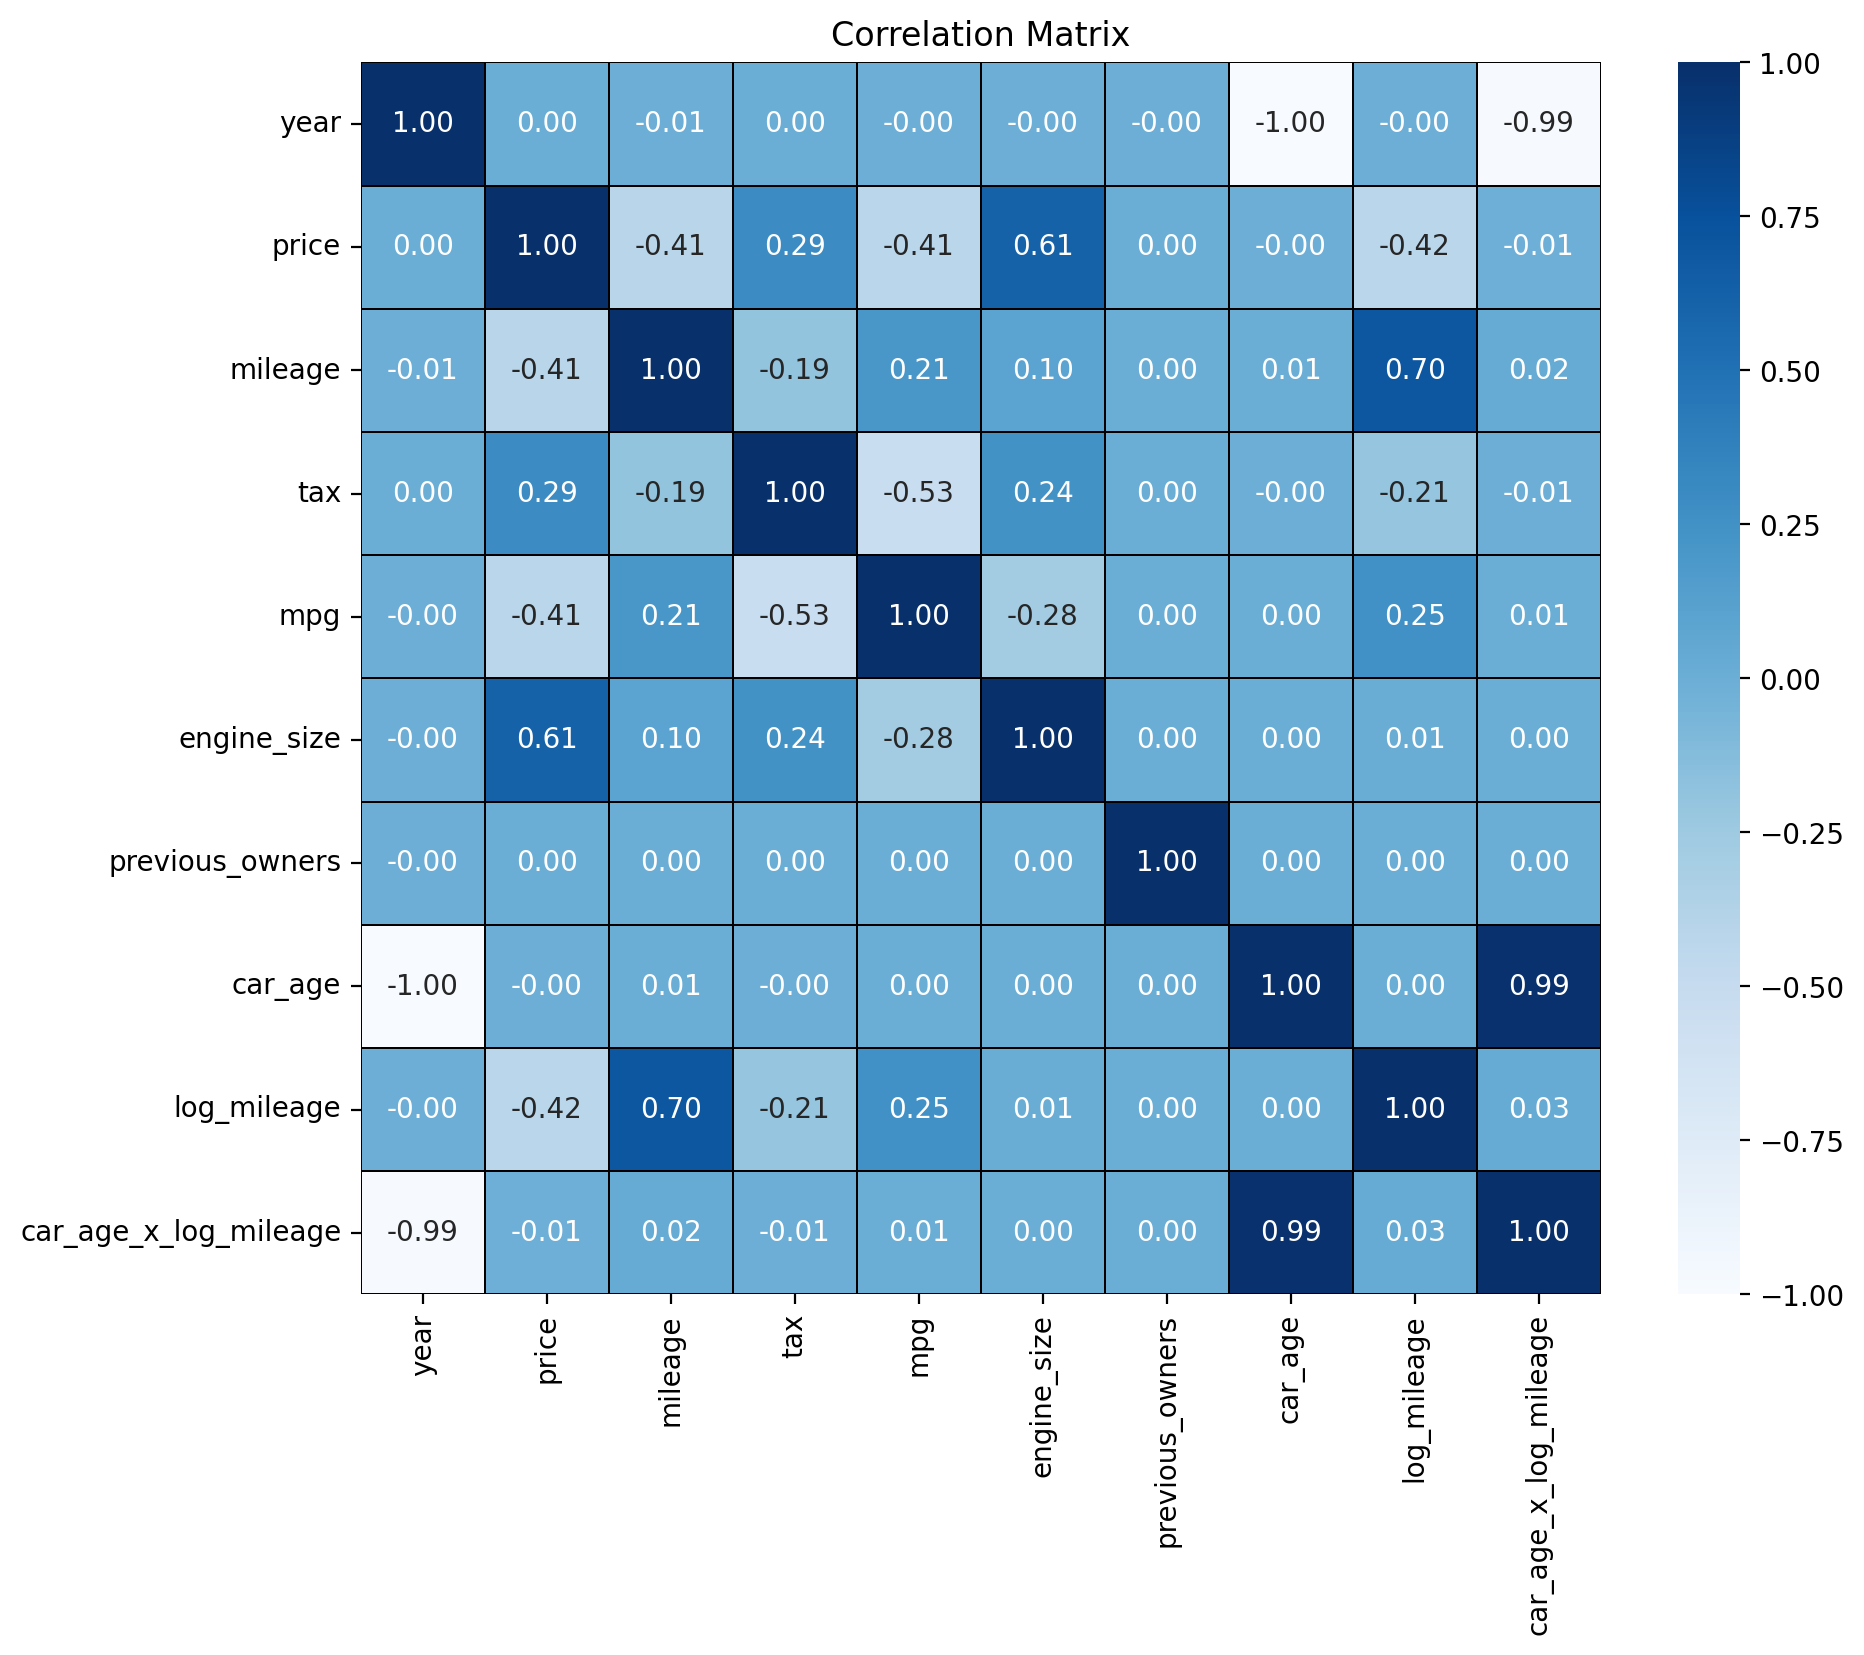

In [81]:
num_cols = train_cars.select_dtypes(include='number').columns.drop("carid")

corr = train_cars[num_cols].corr()

plt.figure(figsize=(10,8),dpi=200)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", linecolor = "black", linewidths=0.01)
plt.title("Correlation Matrix")
plt.show()

The variable year shows a very high correlation with car_age (-1.00), so it is preferable to keep only car_age. The variable mileage is strongly correlated with log_mileage (0.70), so choosing to keep only log_mileage helps normalize the variable and reduces redundancy. Finally, previous_owners does not show significant correlation with any other variable and does not provide relevant information, so it can be removed without compromising the model

In [82]:
train_cars = train_cars.drop(columns=["year", "mileage", "previous_owners", "car_age"])

C:\Users\sofia\AppData\Local\Temp\ipykernel_14360\3014411721.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='brand', data=train_cars, order=train_cars['brand'].value_counts().index, palette="viridis")


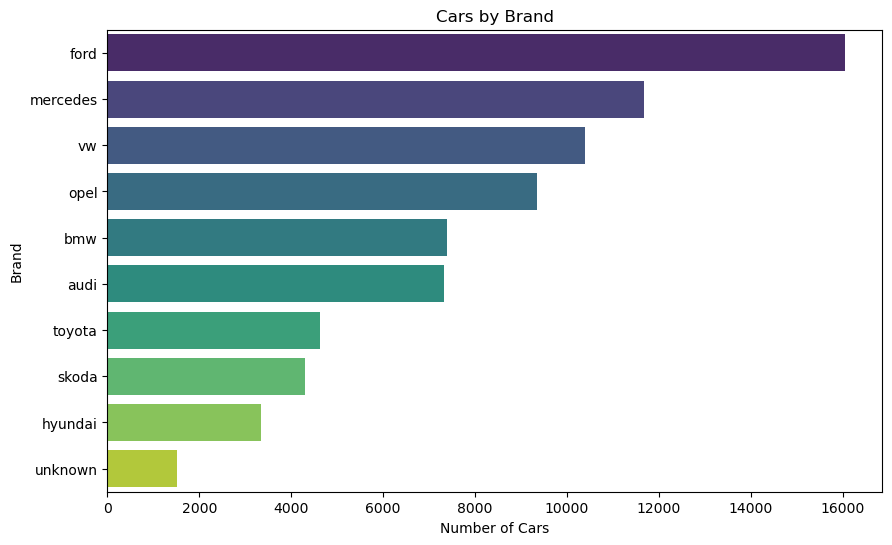

In [28]:
plt.figure(figsize=(10,6))
sns.countplot(y='brand', data=train_cars, order=train_cars['brand'].value_counts().index, palette="viridis")
plt.title("Cars by Brand")
plt.xlabel("Number of Cars")
plt.ylabel("Brand")
plt.show()

The chart shows the distribution of the number of cars by brand, revealing a strong inequality in representation. Ford is the most frequent brand, with around 16,000 cars, standing out from the rest. Next are Mercedes and VW, with approximately 11,000 and 10,000 cars, respectively, while Opel, BMW, and Audi have intermediate numbers, between 7,000 and 8,000 vehicles. Brands such as Toyota, Skoda, and Hyundai are less represented, with values between 3,000 and 5,000 cars, and the “unknown” category has the fewest records, around 1,500. These data suggest that most cars belong to popular brands

## Benchmarking <a class="anchor" id="chapter8"></a>

In [29]:
features = ["log_mileage","engine_size","mpg","tax","brand","model","fuel_type","transmission", "car_age_x_log_mileage"] 
X = train_cars[features] 
y = train_cars["price"] 
X_test = test_cars[features]

In [30]:
def features_fold(X_tr, X_val, y_tr, numeric_cols):
    """
    Encodes categorical variables using training-fold statistics only.

    It uses frequency encoding for brand and model, target encoding for brand
    and one-hot encoding for fuel_type and transmission.

    This function is made to be called inside a cross validation loop to
    prevent data leakage.

    Receives training and validation features for a fold along with
    the target values corresponding to the training features. and returns
    the encoded training and validation features.
    """
    
    X_tr_enc = X_tr.copy()
    X_val_enc = X_val.copy()
    
    # Frequency encoding for brand and model
    for col in ["brand", "model"]:
        freq = X_tr_enc[col].value_counts()
        X_tr_enc[col+"_freq"] = X_tr_enc[col].map(freq)
        X_val_enc[col+"_freq"] = X_val_enc[col].map(freq).fillna(0)
    
    # Target encoding for brand (using only train data)
    brand_avg = y_tr.groupby(X_tr_enc["brand"]).mean()
    X_tr_enc["brand_avg_price"] = X_tr_enc["brand"].map(brand_avg)
    X_val_enc["brand_avg_price"] = X_val_enc["brand"].map(brand_avg)
    
    # Fill NaN in both training and validation sets with median from training set
    median_brand_price = X_tr_enc["brand_avg_price"].median()
    X_tr_enc["brand_avg_price"] = X_tr_enc["brand_avg_price"].fillna(median_brand_price)
    X_val_enc["brand_avg_price"] = X_val_enc["brand_avg_price"].fillna(median_brand_price)
    
    # One-hot encoding for fuel_type and transmission
    X_tr_enc = pd.get_dummies(X_tr_enc, columns=["fuel_type", "transmission"], drop_first=True)
    X_val_enc = pd.get_dummies(X_val_enc, columns=["fuel_type", "transmission"], drop_first=True)
    
    # Align columns
    for col in set(X_tr_enc.columns) - set(X_val_enc.columns):
        X_val_enc[col] = 0
    X_val_enc = X_val_enc[X_tr_enc.columns]

    cols_to_scale = numeric_cols + ["brand_freq", "model_freq", "brand_avg_price"]
    scaler = StandardScaler()
    X_tr_enc[cols_to_scale] = scaler.fit_transform(X_tr_enc[cols_to_scale])
    X_val_enc[cols_to_scale] = scaler.transform(X_val_enc[cols_to_scale])
     
    return X_tr_enc.drop(columns=["brand", "model"]), X_val_enc.drop(columns=["brand", "model"])

In [31]:
def regression_metrics(y_true, y_pred, n_features=None):
    """
    Creates regression metrics to be used in model evaluation.

    Metrics: MAE, RMSE, R-squared, Adjusted R-squared when n_features is provided.

    It receives true and predicted target values and returns a dictionary
    with the computed metrics.
    """
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    if n_features is not None:
        n = len(y_true)
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    else:
        adj_r2 = np.nan
    return {"MAE": mae, "RMSE": rmse, "Adj_R2": adj_r2}

In [32]:
models = {
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=13, n_jobs=-1),
    "DecisionTree": DecisionTreeRegressor(random_state=13),
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "KNN": KNeighborsRegressor(),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=13)
}

In [55]:
numeric_cols_to_scale = ["log_mileage","engine_size","mpg","tax","car_age_x_log_mileage"]

kf = KFold(n_splits=5, shuffle=True, random_state=13)
results = []

for name, model in models.items():
    maes, rmses, r2s, adj_r2s = [], [], [], []
    
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy() 
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        X_tr_enc, X_val_enc = features_fold(X_tr, X_val, y_tr, numeric_cols_to_scale)
        
        model.fit(X_tr_enc, y_tr)
        preds = model.predict(X_val_enc)

        metrics = regression_metrics(y_val, preds, n_features=X_tr_enc.shape[1])
        maes.append(metrics["MAE"])
        rmses.append(metrics["RMSE"])
        adj_r2s.append(metrics["Adj_R2"])
    
    results.append({
        "Model": name,
        "MAE_mean": np.mean(maes),"MAE_std": np.std(maes),
        "RMSE_mean": np.mean(rmses),"RMSE_std": np.std(rmses),
        "AdjR2_mean": np.mean(adj_r2s),"AdjR2_std": np.std(adj_r2s)
    })

In [34]:
results_df = pd.DataFrame(results).sort_values("MAE_mean")
results_df

,Model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,AdjR2_mean,AdjR2_std
0,RandomForest,1403.276284,11.171757,2507.386242,209.182786,0.933236,0.010634
1,DecisionTree,1793.275777,16.550151,3271.858049,150.016692,0.886537,0.011334
5,KNN,1937.685589,20.508554,3400.247283,191.325930,0.877615,0.012329
6,GradientBoostingRegressor,2163.123921,19.433995,3333.748702,163.139930,0.882418,0.010105
4,Lasso,3723.980346,45.517978,5596.675659,120.613536,0.669091,0.007312
3,Ridge,3724.130161,45.583438,5596.749638,120.609031,0.669082,0.007316
2,LinearRegression,3724.222481,45.617865,5596.799413,120.614020,0.669076,0.007317


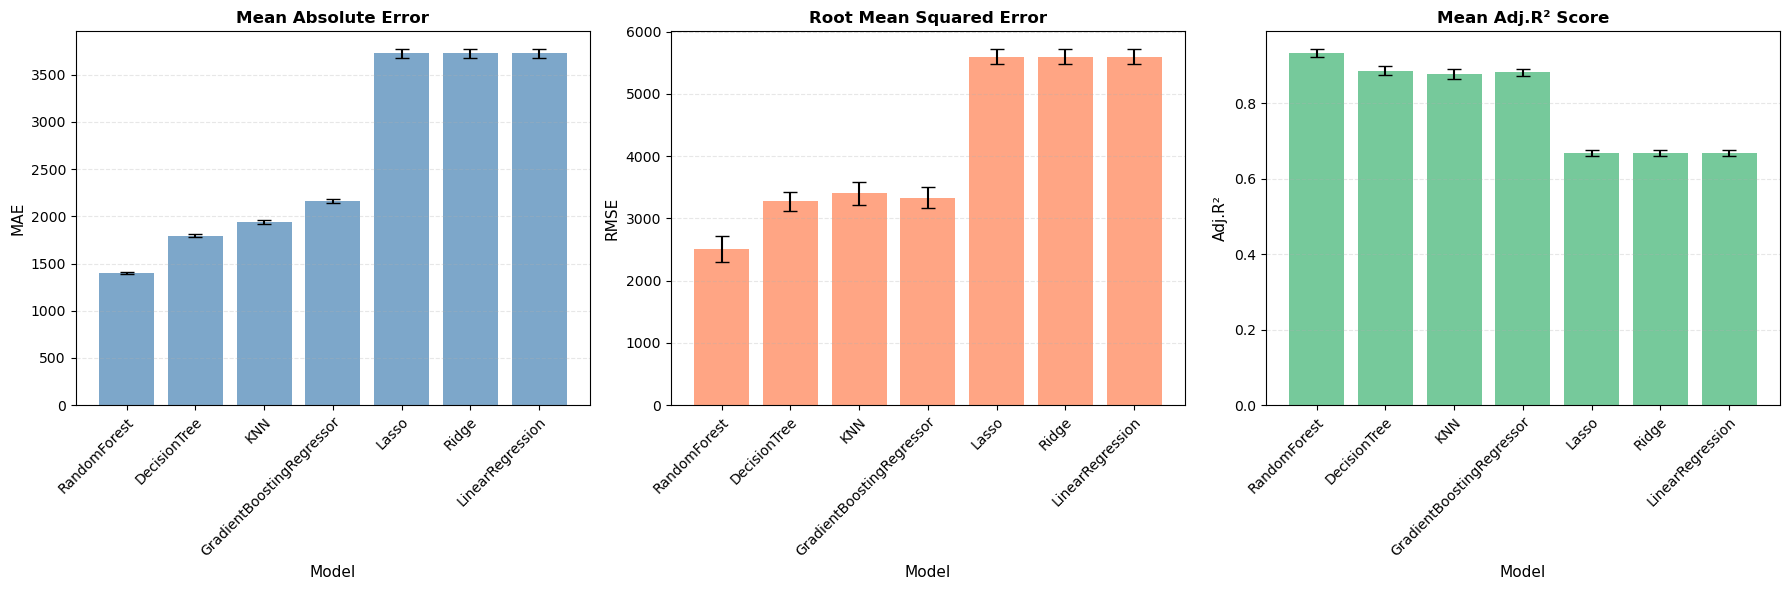

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) 

metrics = [
    ('MAE_mean', 'MAE_std', 'MAE', 'Mean Absolute Error (£)', 'steelblue'),
    ('RMSE_mean', 'RMSE_std', 'RMSE', 'Root Mean Squared Error (£)', 'coral'),
    ('AdjR2_mean', 'AdjR2_std', 'Adj.R²', 'Mean Adj.R² Score', 'mediumseagreen')
]

for i, (mean_col, std_col, ylabel, title, color) in enumerate(metrics):
    axes[i].bar(results_df['Model'], results_df[mean_col], 
                yerr=results_df[std_col], capsize=5, alpha=0.7, color=color)
    
    axes[i].set_xlabel('Model', fontsize=11)
    axes[i].set_ylabel(ylabel, fontsize=11)
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    
    axes[i].set_xticks(range(len(results_df['Model'])))
    axes[i].set_xticklabels(results_df['Model'], rotation=45, ha='right', rotation_mode='anchor')
    
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

The comparative evaluation of the predictive models’ performance was structured using Mean Absolute Error (MAE) and Root Mean Square Error (RMSE), complemented by the adjusted coefficient of determination (Adj. R²). Based on the results obtained through 5-fold cross-validation, the superiority of models built on non-linear decision structures becomes evident. Random Forest (RF) emerged as the best-performing estimator, achieving an MAE of approximately 1403£, which represents a substantially lower error margin compared with linear regression models. The marked difference in performance between forest-based and linear models shows that car depreciation results from non-linear relationships and multiple variables interacting in complex ways


### Hyperparameter Tuning<a class="anchor" id="section_8_1"></a>

Hyperparameter tuning focused on K-Nearest Neighbors (KNN) and Random Forest (RF) due to their superior performance in the preliminary phase. The Decision Tree (DT) was excluded from the ensemble to avoid structural redundancy and error correlation, as RF is already an aggregate of trees. Hybridizing RF with KNN through an ensemble allows for the compensation of systematic errors within each approach, enhancing the robustness and generalization capability of the final model

In [36]:
X_train_final, X_test_final = features_fold(X, X_test, y, numeric_cols_to_scale)

#### Random Forest<a class="anchor" id="section_8_1_1"></a>

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

rf = RandomForestRegressor(random_state=13, n_jobs=-1)

param_grid = {
    'n_estimators': randint(100, 1000),
    'max_depth': [None, 10, 15, 20, 25, 30, 50],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': [None, 'sqrt', 'log2']
}

random_search = RandomizedSearchCV(rf,param_distributions=param_grid,n_iter=50, cv=5,scoring='neg_mean_absolute_error',n_jobs=-1,random_state=13,verbose=2)

random_search.fit(X_train_final, y)
best_rf = random_search.best_estimator_

best_rf.fit(X_train_final, y)
y_pred_rf_test = best_rf.predict(X_test_final)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


In [ ]:
print("Best RF parameters:", random_search.best_params_)
print("Tuning RF CV MAE (£):", -random_search.best_score_)

Best RF parameters: {'max_depth': 25, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 7, 'n_estimators': 522}
Tuning RF CV MAE: 1391.2568438401256


#### KNN <a class="anchor" id="section_8_1_2"></a>

In [39]:
knn = KNeighborsRegressor()

param_grid = {
    'n_neighbors': randint(3, 51),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}

random_search = RandomizedSearchCV(knn,param_distributions=param_grid,n_iter=50,cv=5,scoring='neg_mean_absolute_error',n_jobs=-1,random_state=13,verbose=2)

random_search.fit(X_train_final, y)
best_knn = random_search.best_estimator_

best_knn.fit(X_train_final, y)
y_pred_knn_test = best_knn.predict(X_test_final)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


In [ ]:
print("Best KNN parameters:", random_search.best_params_)
print("Tuning KNN CV MAE (£):", -random_search.best_score_)

Best KNN parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'p': 2, 'weights': 'distance'}
Tuning KNN CV MAE: 1735.0056924615546


#### Performance Comparison <a class="anchor" id="chapter_8_1_3"></a>

<table style="width:80%; font-size:12px; border-collapse: collapse; margin: 0 auto; text-align: left; font-family: Arial, sans-serif;">
  <thead>
    <tr style="background-color:#f2f2f2; text-align:left; color: black;">
      <th style="border:1px solid #ddd; padding: 10px;">Modelo</th>
      <th style="border:1px solid #ddd; padding: 10px;">MAE (Base Model)</th>
      <th style="border:1px solid #ddd; padding: 10px;">MAE (Tuned Model)</th>
      <th style="border:1px solid #ddd; padding: 10px;">Melhoria (%)</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border:1px solid #ddd; padding: 8px;">Random Forest</td>
      <td style="border:1px solid #ddd; padding: 8px;">1403.276284</td>
      <td style="border:1px solid #ddd; padding: 8px;">1391.256843</td>
      <td style="border:1px solid #ddd; padding: 8px; font-weight: bold; color: #28a745;">0.86%</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding: 8px;">K-Nearest Neighbors (KNN)</td>
      <td style="border:1px solid #ddd; padding: 8px;">1937.685589</td>
      <td style="border:1px solid #ddd; padding: 8px;">1735.005692</td>
      <td style="border:1px solid #ddd; padding: 8px; font-weight: bold; color: #28a745;">10.46%</td>
    </tr>
  </tbody>
</table>

Hyperparameter tuning highlighted the robustness of Random Forest, which achieved a marginal gain of 0.86%, indicating that its base configuration was already operating near the global optimum. In contrast, KNN demonstrated high parametric sensitivity, with a 10.46% improvement after a rigorous adjustment. Based on this performance hierarchy, the final model was consolidated through a weighted ensemble: $0.6 \times RF + 0.4 \times KNN$. Assigning a 60% weight to Random Forest is justified by its superiority in absolute precision and predictive stability, while the remaining 40% allows KNN's to complement the system. This hybridization allows for the mitigation of systematic errors from each paradigm, resulting in a more robust model

## Deployment <a class="anchor" id="chapter9"></a>

In [ ]:
def export_kaggle_submission(test_cars, X_reference, y_reference, best_rf, best_knn, numeric_cols, filename="submission.csv"):
    df_test = test_cars.copy()
    ids = df_test['carid'].copy()

    df_test = column_treatment(df_test)
    df_test = convert_to_int(df_test, cols_int)
    df_test = convert_to_positive(df_test, cols_positive)
    df_test = handle_outliers_domain(df_test)
    df_test = string_cleaning(df_test)
    df_test = create_features(df_test)

    
    for col in ["brand", "model", "fuel_type", "transmission"]:
        df_test[col] = df_test[col].fillna("unknown")
    

    df_test = df_test[X_reference.columns]
    _, X_test_ = features_fold(X_reference, df_test, y_reference, numeric_cols)

    y_pred_rf = best_rf.predict(X_test_)
    y_pred_knn = best_knn.predict(X_test_)
    final_prices = (0.6 * y_pred_rf) + (0.4 * y_pred_knn)

    submission = pd.DataFrame({
        'carid': ids,
        'price': final_prices
    })
    
    submission.to_csv(filename, index=False)
    print(f"File '{filename}' created with success using {X_test_.shape[1]} features")
    
    return submission

In [90]:
df_final = export_kaggle_submission(test_cars,X,y,best_rf,best_knn,numeric_cols_to_scale)

File 'submission.csv' created with success using 17 features


## Conclusions <a class="anchor" id="chapter10"></a>

The results show that feature engineering was essential to improve model performance, through the inclusion of logarithmic transformations and interaction features. Tree-based models outperformed linear models, which showed the importance of non-linear relationships in vehicle pricing.

Among all tested approaches, the tuned Random Forest model achieved the lowest MAE. Although an ensemble combining Random Forest and KNN was explored, it did not provide a sufficiently consistent improvement to justify its use.